In [1]:
# 1.1
import nest_asyncio
nest_asyncio.apply()

In [2]:
# 1.0
# Load any environment variables
# No need with ollama
from dotenv import load_dotenv
load_dotenv()

False

In [3]:
# 1.1
from llama_index.core.agent.workflow import AgentWorkflow
from llama_index.core import Settings
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding

/home/ashok/langchain/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [33]:
# 2.1
Settings.llm = Ollama(
                                     model=  "qwen3.5:latest",  #  Try these:  "deepseek-r1:7b", #          "llama3.2:latest",
                                     request_timeout=120.0,
                                     temperature = 0.4,
                                     mirostat = 0)

llm = Settings.llm


In [34]:
# 2.2
Settings.embed_model = OllamaEmbedding(
                                        model_name="nomic-embed-text",      # Using foundational model may be overkill
                                        base_url="http://localhost:11434",
                                       )

In [35]:
# 2.31
def multiply(a: float, b: float) -> float:
    """Multiply two numbers and returns the product"""
    return a * b

# 2.32
def add(a: float, b: float) -> float:
    """Add two numbers and returns the sum"""
    return a + b

In [43]:
# 3.0
workflow = AgentWorkflow.from_tools_or_functions(
    [multiply, add],  
    llm=llm,
    system_prompt="You are an agent that can perform basic mathematical operations using tools. While answering the question, also let us know which tools you are using."
)

In [37]:
async def main():
    response = await workflow.run(user_msg="What is 20+(2*4)?")
    print(response)



In [38]:
await main()

The answer is **28**.

Here's the calculation:
- First, multiply 2 × 4 = 8
- Then, add 20 + 8 = 28

I used the `multiply` tool to calculate 2×4 and the `add` tool to add 20 to the result.


### See this [example also](https://developers.llamaindex.ai/python/examples/agent/agent_workflow_basic/#starlight__mobile-toc)

In [39]:
from llama_index.core.agent.workflow import FunctionAgent

In [41]:
workflow = FunctionAgent(
    tools = [multiply, add],
    llm=llm,
    system_prompt="You are an agent that can perform basic mathematical operations using tools. While answering the question, also let us know which tools you are using."
)

In [44]:
async def main():
    response = await workflow.run(user_msg="What is 20+(2*4)?")
    print(response)



In [45]:
await main()

20 + (2 * 4) = 28

Here's the step-by-step calculation:
1. First, multiply 2 × 4 = 8
2. Then, add 20 + 8 = 28

The answer is **28**.


#### What is meant by '.from_tools_or_functions'. After all tools are functions?

**.from_tools_or_functions** is a class method that accepts a list of either tools (instances of *BaseTool*) or plain Python functions. If you pass a function, it is automatically wrapped as a FunctionTool; if you pass a tool, it is used as-is. This allows flexibility: you can provide either pre-wrapped tools or raw functions. See API reference.

Here’s a code example showing how .from_tools_or_functions works with both functions and tools:

In [46]:
from llama_index.core.agent.workflow import AgentWorkflow
from llama_index.core.tools import FunctionTool




Settings.llm = Ollama(
                                     model=  "qwen3.5:latest",  #  Try these:  "deepseek-r1:7b", #          "llama3.2:latest",
                                     request_timeout=120.0,
                                     temperature = 0.4,
                                     mirostat = 0)

llm = Settings.llm



def add(a: int, b: int) -> int:
    return a + b

# You can use a plain function...
plain_function = add

# ...or wrap it as a FunctionTool
tool = FunctionTool.from_defaults(fn=add)

#llm = OpenAI(model="gpt-4o")

# Both can be passed to from_tools_or_functions
workflow = AgentWorkflow.from_tools_or_functions(
    tools_or_functions=[plain_function, tool],
    llm=llm,
    system_prompt="You are a helpful assistant."
)

response = await workflow.run(user_msg="What is 2 + 3?")
print(response)


2 + 3 = 5


Can I not use FunctionAgent in the above example?

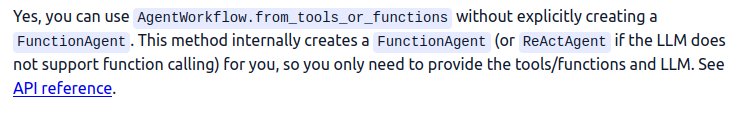

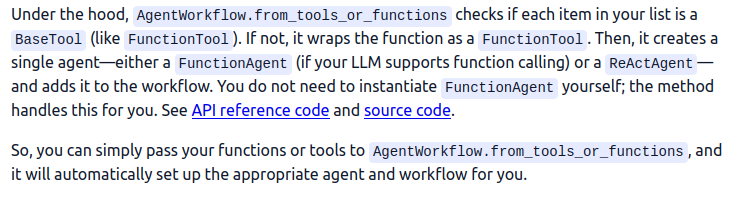

In [ ]:

# 2.1
"""
# Quick but output is NOT that good.
Settings.llm = Ollama(
                                     model="llama3.2:latest",
                                     request_timeout=120.0,
                                     temperature = 0.4,
                                     mirostat = 0)

"""

# Takes a lot of time but the output is better
Settings.llm = OpenAILike(
                          temperature=0.7,
                          model= "llama-3.2-3b-instruct:q8_0",   # "gpt-3.5-turbo",  # "gemma-3-27b-it",  #          # Can be any name, not necessarily openai's gpt
                          api_base="http://127.0.0.1:8080/v1",
                          api_key="fake",
                          timeout= 1000.0,
                          is_chat_model = True,
                          is_function_calling_model=True,
                          )

# 2.2
Settings.embed_model = OllamaEmbedding(
                                        model_name="nomic-embed-text",      # Using foundational model may be overkill
                                        base_url="http://localhost:11434",
                                       )


def multiply(a: float, b: float) -> float:
    """Multiply two numbers and returns the product"""
    return a * b

def add(a: float, b: float) -> float:
    """Add two numbers and returns the sum"""
    return a + b

llm = Settings.llm

workflow = AgentWorkflow.from_tools_or_functions(
    [multiply, add],
    llm=llm,
    system_prompt="You are an agent that can perform basic mathematical operations using tools."
)

async def main():
    response = await workflow.run(user_msg="What is 20+(2*4)?")
    print(response)

if __name__ == "__main__":
    import asyncio
    asyncio.run(main())